In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('city_day.csv')

# Keep city names separately before dropping
city_names = df['City']

# Drop unnecessary columns
df = df.drop(columns=['City', 'Date', 'AQI_Bucket'])

# Fill missing values
df = df.fillna(df.mean())

print("Shape:", df.shape)

Saving city_day.csv to city_day (1).csv
Shape: (29531, 13)


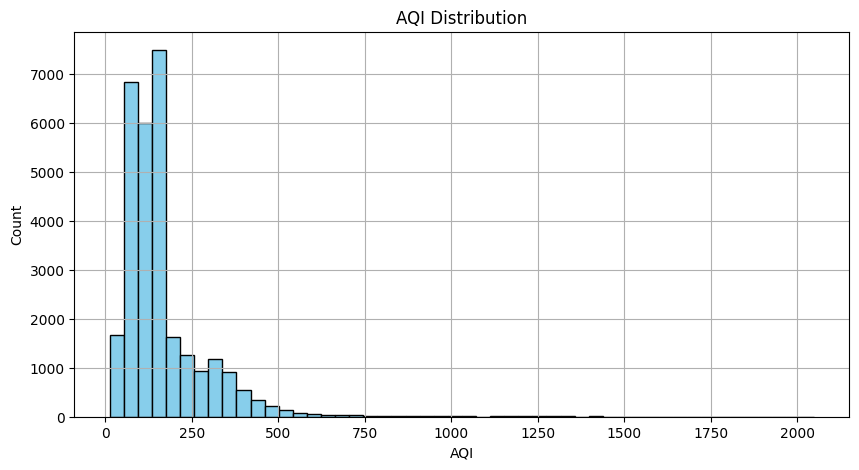

<Figure size 1500x500 with 0 Axes>

In [ ]:
plt.figure(figsize=(10, 5))
df['AQI'].hist(bins=50, color='skyblue', edgecolor='black')
plt.title('AQI Distribution')
plt.xlabel('AQI')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(15, 5))
df.groupby('City')['AQI'].mean().sort_values(ascending=False).plot(kind='bar', color='salmon') if 'City' in df.columns else None
plt.tight_layout()
plt.show()

In [ ]:
X = df.drop(columns=['AQI'])
y = df['AQI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (23624, 12)
Testing size: (5907, 12)


In [ ]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Linear Regression → MAE:", round(mean_absolute_error(y_test, y_pred_lr), 2), "R2:", round(r2_score(y_test, y_pred_lr), 2))

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest     → MAE:", round(mean_absolute_error(y_test, y_pred_rf), 2), "R2:", round(r2_score(y_test, y_pred_rf), 2))

# XGBoost
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("XGBoost           → MAE:", round(mean_absolute_error(y_test, y_pred_xgb), 2), "R2:", round(r2_score(y_test, y_pred_xgb), 2))

Linear Regression → MAE: 31.54 R2: 0.8
Random Forest     → MAE: 20.36 R2: 0.88
XGBoost           → MAE: 21.53 R2: 0.88


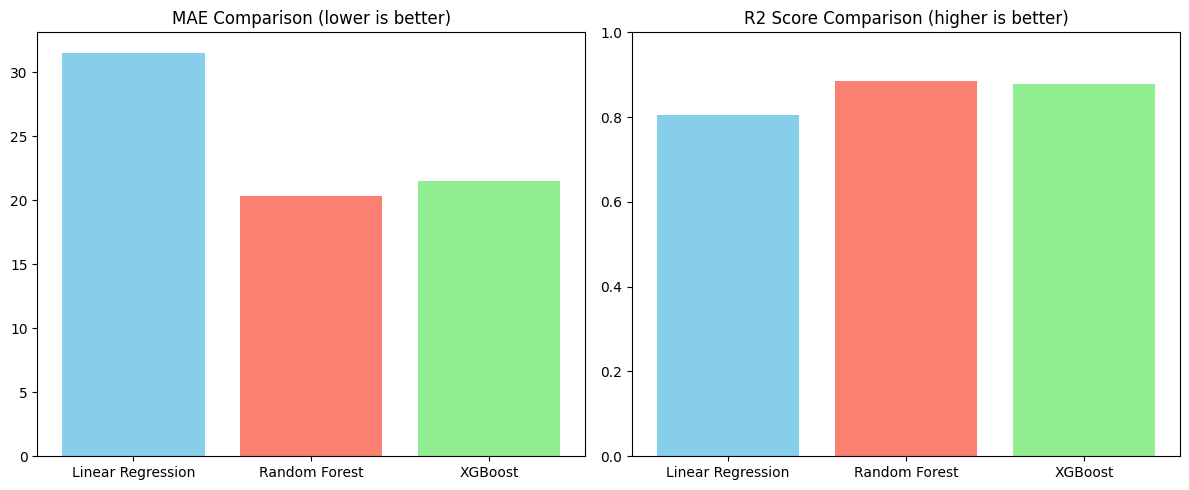

In [ ]:
models = ['Linear Regression', 'Random Forest', 'XGBoost']
mae_scores = [mean_absolute_error(y_test, y_pred_lr), mean_absolute_error(y_test, y_pred_rf), mean_absolute_error(y_test, y_pred_xgb)]
r2_scores = [r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_rf), r2_score(y_test, y_pred_xgb)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.bar(models, mae_scores, color=['skyblue', 'salmon', 'lightgreen'])
ax1.set_title('MAE Comparison (lower is better)')
ax2.bar(models, r2_scores, color=['skyblue', 'salmon', 'lightgreen'])
ax2.set_title('R2 Score Comparison (higher is better)')
ax2.set_ylim(0, 1)
plt.tight_layout()
plt.show()

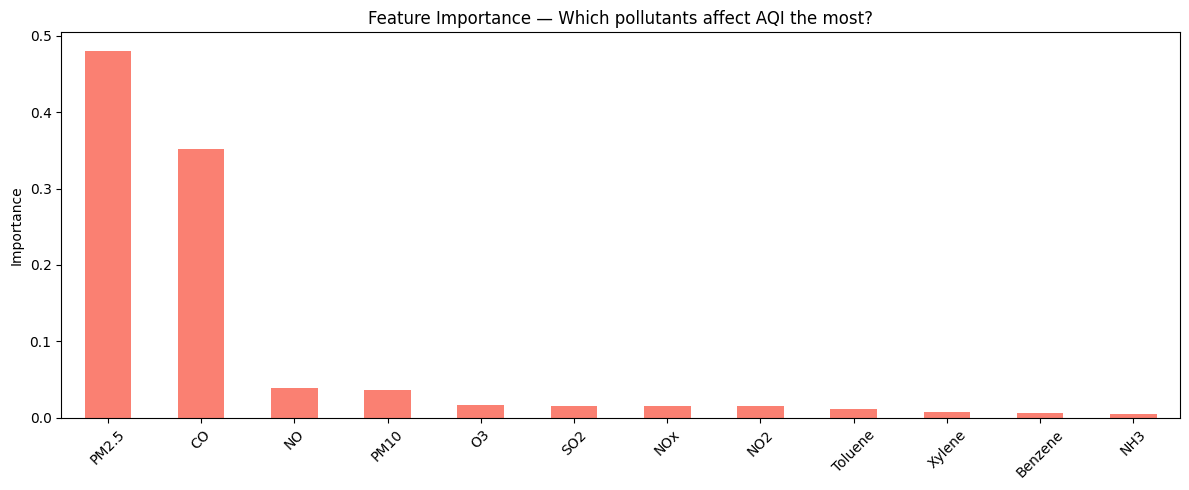

In [ ]:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).plot(kind='bar', color='salmon', figsize=(12, 5))
plt.title('Feature Importance — Which pollutants affect AQI the most?')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
joblib.dump(rf, 'aqi_model.pkl')
print("✅ Model saved!")

def get_aqi_category(aqi):
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Satisfactory'
    elif aqi <= 200:
        return 'Moderate'
    elif aqi <= 300:
        return 'Poor'
    elif aqi <= 400:
        return 'Very Poor'
    else:
        return 'Severe'

# Get test indices to match city names
test_indices = X_test[:10].index

y_pred_rf_test = rf.predict(X_test[:10])

print("\nAQI Predictions with Cities:")
print("-" * 55)
for i, (pred, actual) in enumerate(zip(y_pred_rf_test, y_test[:10].values)):
    city = city_names.iloc[test_indices[i]]
    print(f"{city:<20} Predicted: {pred:.1f} ({get_aqi_category(pred)}) | Actual: {actual:.1f} ({get_aqi_category(actual)})")

✅ Model saved!

AQI Predictions with Cities:
-------------------------------------------------------
Mumbai               Predicted: 166.5 (Moderate) | Actual: 166.5 (Moderate)
Mumbai               Predicted: 166.5 (Moderate) | Actual: 166.5 (Moderate)
Patna                Predicted: 138.0 (Moderate) | Actual: 137.0 (Moderate)
Patna                Predicted: 185.6 (Moderate) | Actual: 190.0 (Moderate)
Lucknow              Predicted: 353.6 (Very Poor) | Actual: 339.0 (Very Poor)
Gurugram             Predicted: 92.3 (Satisfactory) | Actual: 82.0 (Satisfactory)
Jorapokhar           Predicted: 164.4 (Moderate) | Actual: 166.5 (Moderate)
Jaipur               Predicted: 139.3 (Moderate) | Actual: 138.0 (Moderate)
Hyderabad            Predicted: 117.5 (Moderate) | Actual: 111.0 (Moderate)
Bengaluru            Predicted: 82.5 (Satisfactory) | Actual: 125.0 (Moderate)
